In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings('ignore')
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


### Cell 2: 데이터 로드 및 전처리

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/kzming2007/UR3_Cobot_ML/refs/heads/main/dataset/ur3_cobotops.csv")

# 결측치 제거
df_clean = df.dropna().copy()

# Robot_ProtectiveStop: 문자열 → bool 변환
df_clean['ProtectiveStop_bool'] = df_clean['Robot_ProtectiveStop'].apply(
    lambda x: True if str(x).strip().lower() == 'true' else False
)

# 피처 그룹 정의
current_cols = ['Current_J0', 'Current_J1', 'Current_J2',
                'Current_J3', 'Current_J4', 'Current_J5', 'Tool_current']

speed_cols = ['Speed_J0', 'Speed_J1', 'Speed_J2',
              'Speed_J3', 'Speed_J4', 'Speed_J5']

temp_cols = ['Temperature_T0', 'Temperature_J1', 'Temperature_J2',
             'Temperature_J3', 'Temperature_J4', 'Temperature_J5']

# 피처 그룹
group_A = current_cols                          # 7개: 전류
group_B = current_cols + speed_cols             # 13개: 전류 + 속도
group_C = current_cols + speed_cols + temp_cols  # 19개: 전체

# 시계열/라벨 변수 (클러스터링 입력 제외)
excluded = ['Num', 'Timestamp', 'cycle ', 'Robot_ProtectiveStop', 'grip_lost', 'ProtectiveStop_bool']

print(f"전체: {len(df)}행 → 결측치 제거 후: {len(df_clean)}행")
print(f"\n피처 그룹:")
print(f"  Group A (전류):       {len(group_A)}개 — {group_A}")
print(f"  Group B (전류+속도):  {len(group_B)}개")
print(f"  Group C (전체):       {len(group_C)}개")

전체: 7409행 → 결측치 제거 후: 7355행

피처 그룹:
  Group A (전류):       7개 — ['Current_J0', 'Current_J1', 'Current_J2', 'Current_J3', 'Current_J4', 'Current_J5', 'Tool_current']
  Group B (전류+속도):  13개
  Group C (전체):       19개


### Cell 3: 기존 1D 분석 재현 및 문제점 시각화

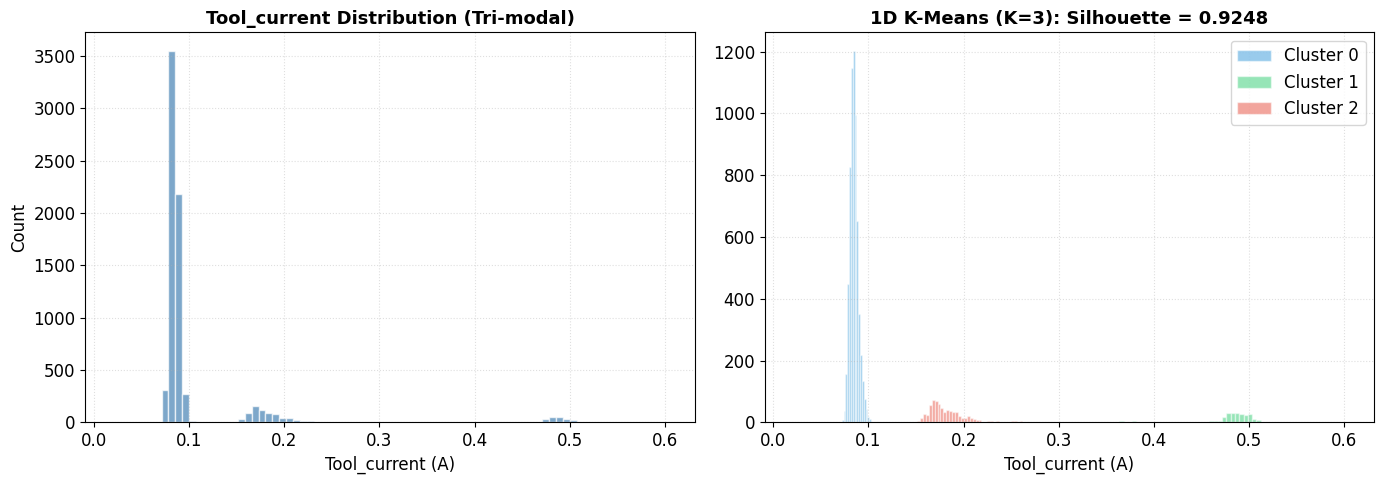

[기존 분석의 문제점]

  Silhouette Score = 0.9248 (매우 높음)

  ⚠️ 그러나 이것은 '좋은 클러스터링'이 아님:
  1. Tool_current가 삼봉 분포(tri-modal)이므로 K=3으로 나누면
     수학적으로 '구간 나누기(thresholding)'와 동일함
  2. 1차원 K-Means는 거리 계산의 다차원 장점을 전혀 활용하지 못함
  3. 19개 센서 변수 중 1개만 사용하는 것은 정보 손실이 극심함
  4. '변수를 추가하면 성능이 떨어진다'는 결론은
     클러스터링의 취지를 놓친 것임

  ➡️ 올바른 접근: 전체 피처 공간에서 '로봇 운영 상태'를 발견하는 것



In [4]:
# ── 기존 접근: Tool_current 1차원 K-Means ──
X_1d = df_clean[['Tool_current']].values
scaler_1d = StandardScaler()
X_1d_scaled = scaler_1d.fit_transform(X_1d)

km_1d = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_1d = km_1d.fit_predict(X_1d_scaled)
sil_1d = silhouette_score(X_1d_scaled, labels_1d)

# 시각화: 왜 이것이 "클러스터링"이 아닌 "구간 나누기"인지 보여줌
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (좌) Tool_current 분포 — 삼봉 분포임을 확인
axes[0].hist(df_clean['Tool_current'], bins=80, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_title('Tool_current Distribution (Tri-modal)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tool_current (A)')
axes[0].set_ylabel('Count')
axes[0].grid(True, linestyle=':', alpha=0.4)

# (우) 1D K-Means 결과 — 사실상 구간 나누기
colors_1d = {0: '#3498db', 1: '#2ecc71', 2: '#e74c3c'}
for c_id in range(3):
    mask = labels_1d == c_id
    axes[1].hist(df_clean.loc[mask, 'Tool_current'], bins=60, alpha=0.5,
                 color=list(colors_1d.values())[c_id], label=f'Cluster {c_id}', edgecolor='white')
axes[1].set_title(f'1D K-Means (K=3): Silhouette = {sil_1d:.4f}', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tool_current (A)')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

print("=" * 70)
print("[기존 분석의 문제점]")
print("=" * 70)
print(f"""
  Silhouette Score = {sil_1d:.4f} (매우 높음)

  ⚠️ 그러나 이것은 '좋은 클러스터링'이 아님:
  1. Tool_current가 삼봉 분포(tri-modal)이므로 K=3으로 나누면
     수학적으로 '구간 나누기(thresholding)'와 동일함
  2. 1차원 K-Means는 거리 계산의 다차원 장점을 전혀 활용하지 못함
  3. 19개 센서 변수 중 1개만 사용하는 것은 정보 손실이 극심함
  4. '변수를 추가하면 성능이 떨어진다'는 결론은
     클러스터링의 취지를 놓친 것임

  ➡️ 올바른 접근: 전체 피처 공간에서 '로봇 운영 상태'를 발견하는 것
""")

### Cell 4: 피처 분포 시각화: 3행 (전류 / 속도 / 온도) 

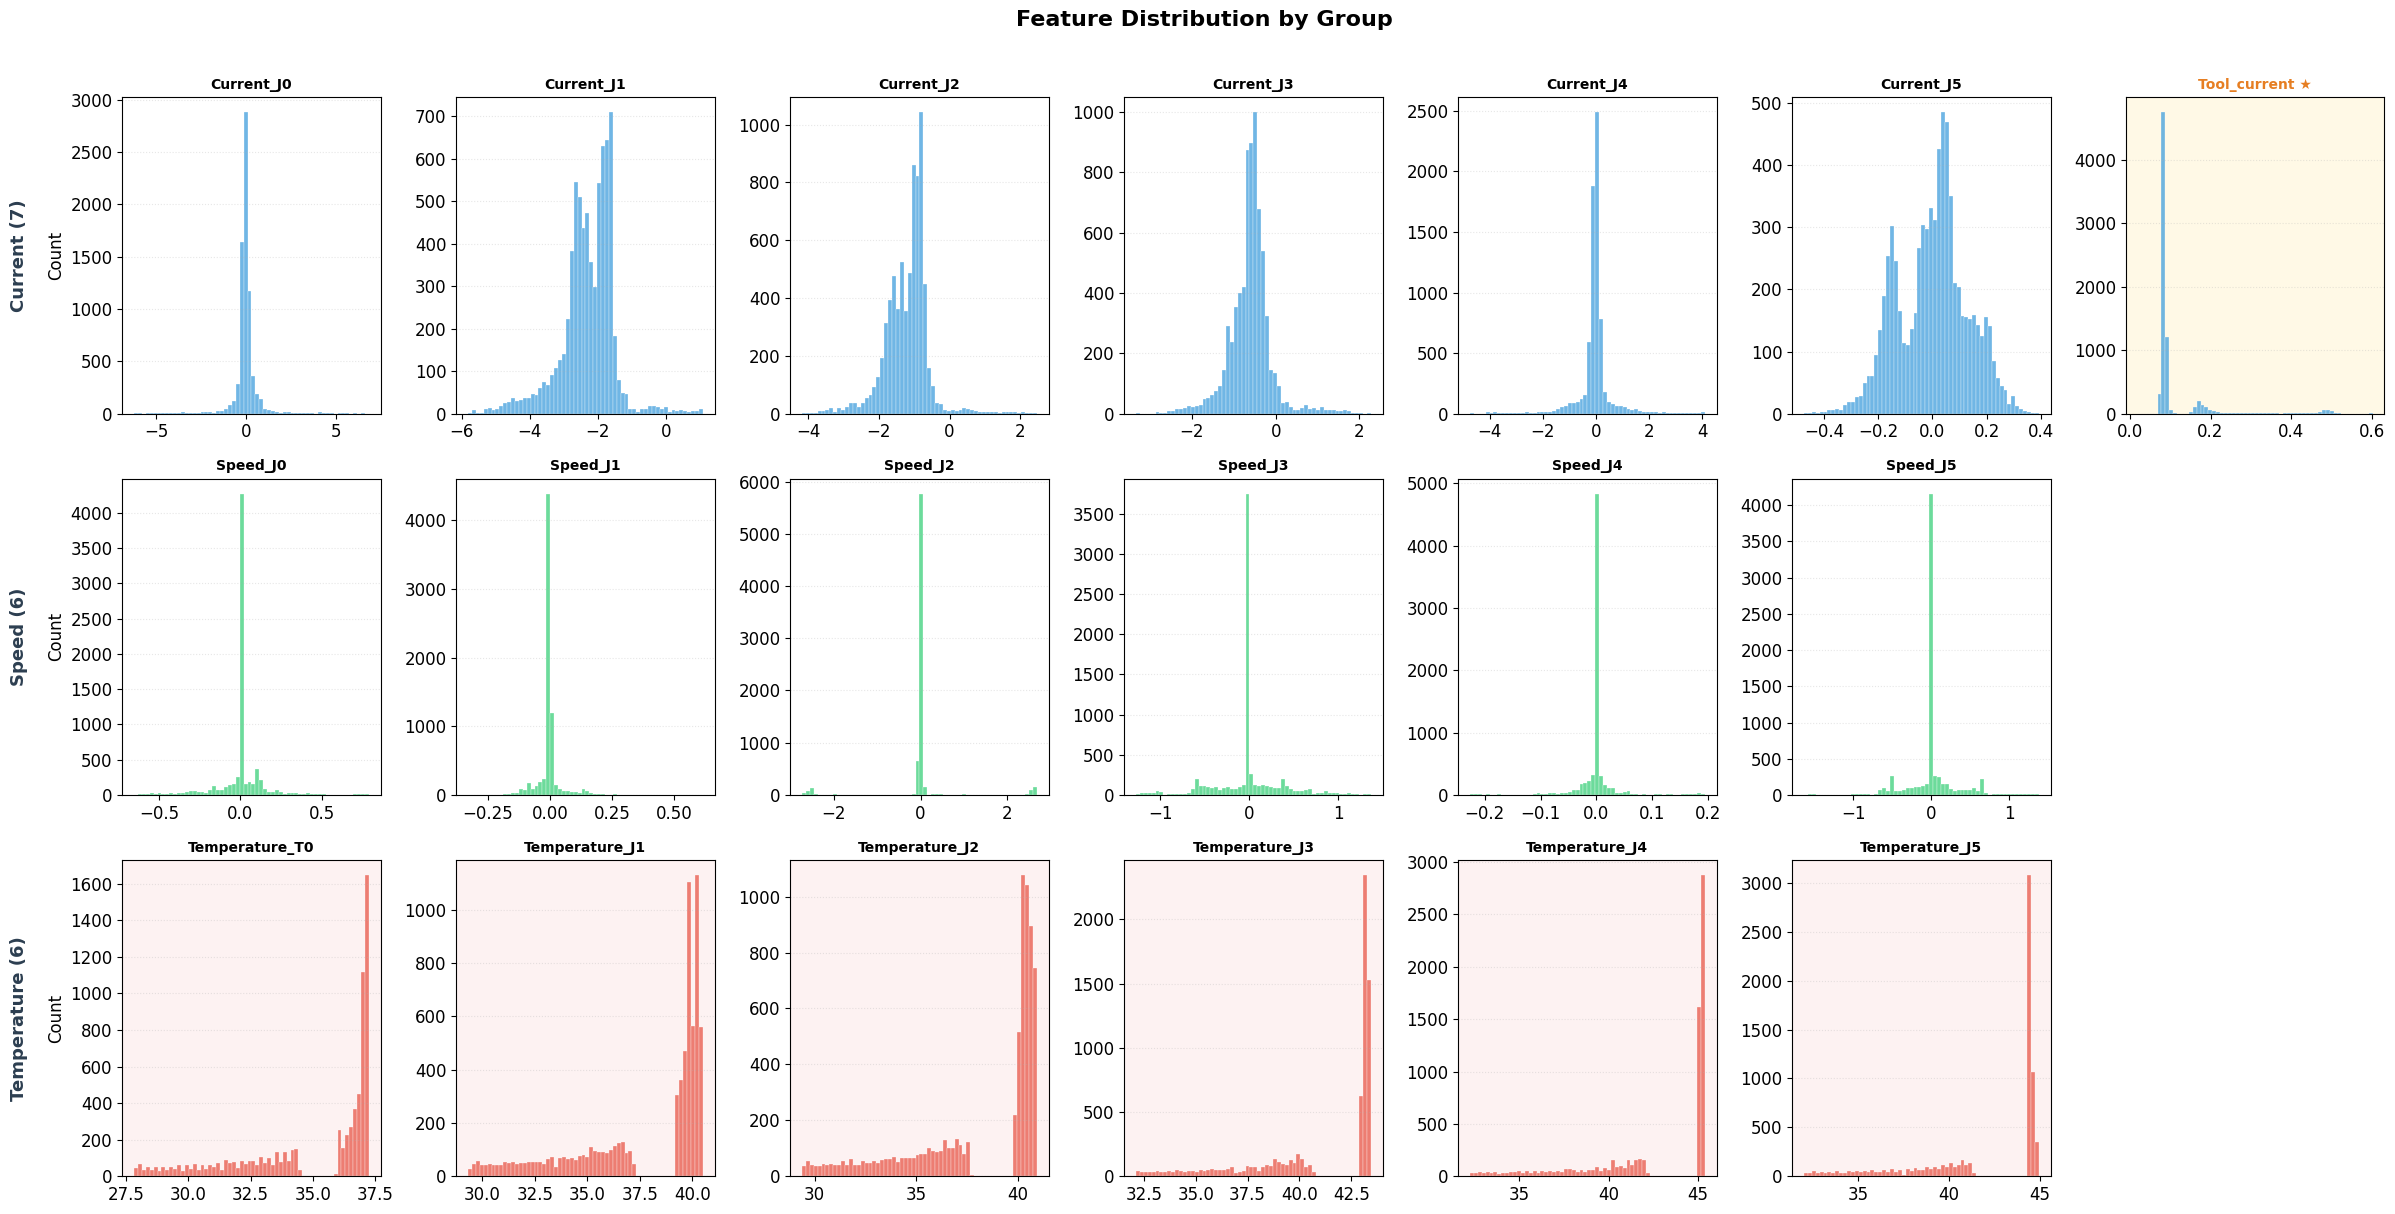

[피처 분포 관찰]

  1. Tool_current: 삼봉 분포 (0.08, 0.18, 0.49A 부근)
     → 3가지 하중 상태가 명확히 분리됨
     → 단, 1D 클러스터링은 구간 나누기에 불과

  2. Current_J0~J5: 각 관절마다 분포 형태가 다름
     → 다양한 정보를 담고 있음 (클러스터링 입력으로 적합)

  3. Speed_J0~J5: 0 근처에 집중 + 양쪽 꼬리
     → 로봇이 정지해 있는 시간이 많고, 동작 시 다양한 속도

  4. Temperature_T0~J5: ⚠️ 6개 분포가 거의 동일!
     → 상관계수 0.993~1.000 → 사실상 같은 변수의 복사본
     → 클러스터링에 포함하면 중복 정보가 PC1을 지배



In [5]:
# ══════════════════════════════════════════════
# 피처 분포 시각화: 3행 (전류 / 속도 / 온도) 
# ══════════════════════════════════════════════
fig, axes = plt.subplots(3, 7, figsize=(24, 12))

# ── Row 1: 전류 (7개) ──
current_cols = ['Current_J0', 'Current_J1', 'Current_J2',
                'Current_J3', 'Current_J4', 'Current_J5', 'Tool_current']
for i, col in enumerate(current_cols):
    ax = axes[0][i]
    ax.hist(df_clean[col], bins=60, color='#3498db', alpha=0.7, edgecolor='white', linewidth=0.3)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Count' if i == 0 else '')
    ax.grid(True, linestyle=':', alpha=0.3, axis='y')
    # Tool_current만 삼봉 표시
    if col == 'Tool_current':
        ax.set_facecolor('#fff9e6')
        ax.set_title('Tool_current ★', fontsize=10, fontweight='bold', color='#e67e22')

axes[0][0].annotate('Current (7)', xy=(0, 0.5), xycoords='axes fraction',
                     xytext=(-0.4, 0.5), fontsize=13, fontweight='bold',
                     color='#2c3e50', ha='center', va='center', rotation=90)

# ── Row 2: 속도 (6개) — 마지막 칸 비움 ──
speed_cols = ['Speed_J0', 'Speed_J1', 'Speed_J2',
              'Speed_J3', 'Speed_J4', 'Speed_J5']
for i, col in enumerate(speed_cols):
    ax = axes[1][i]
    ax.hist(df_clean[col], bins=60, color='#2ecc71', alpha=0.7, edgecolor='white', linewidth=0.3)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Count' if i == 0 else '')
    ax.grid(True, linestyle=':', alpha=0.3, axis='y')
axes[1][6].axis('off')

axes[1][0].annotate('Speed (6)', xy=(0, 0.5), xycoords='axes fraction',
                     xytext=(-0.4, 0.5), fontsize=13, fontweight='bold',
                     color='#2c3e50', ha='center', va='center', rotation=90)

# ── Row 3: 온도 (6개) — 마지막 칸 비움 ──
temp_cols = ['Temperature_T0', 'Temperature_J1', 'Temperature_J2',
             'Temperature_J3', 'Temperature_J4', 'Temperature_J5']
for i, col in enumerate(temp_cols):
    ax = axes[2][i]
    ax.hist(df_clean[col], bins=60, color='#e74c3c', alpha=0.7, edgecolor='white', linewidth=0.3)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Count' if i == 0 else '')
    ax.grid(True, linestyle=':', alpha=0.3, axis='y')
    ax.set_facecolor('#fdf2f2')
axes[2][6].axis('off')

axes[2][0].annotate('Temperature (6)', xy=(0, 0.5), xycoords='axes fraction',
                     xytext=(-0.4, 0.5), fontsize=13, fontweight='bold',
                     color='#2c3e50', ha='center', va='center', rotation=90)

fig.suptitle('Feature Distribution by Group', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── 핵심 관찰 출력 ──
print("=" * 65)
print("[피처 분포 관찰]")
print("=" * 65)
print("""
  1. Tool_current: 삼봉 분포 (0.08, 0.18, 0.49A 부근)
     → 3가지 하중 상태가 명확히 분리됨
     → 단, 1D 클러스터링은 구간 나누기에 불과

  2. Current_J0~J5: 각 관절마다 분포 형태가 다름
     → 다양한 정보를 담고 있음 (클러스터링 입력으로 적합)

  3. Speed_J0~J5: 0 근처에 집중 + 양쪽 꼬리
     → 로봇이 정지해 있는 시간이 많고, 동작 시 다양한 속도

  4. Temperature_T0~J5: ⚠️ 6개 분포가 거의 동일!
     → 상관계수 0.993~1.000 → 사실상 같은 변수의 복사본
     → 클러스터링에 포함하면 중복 정보가 PC1을 지배
""")

In [4]:
# ══════════════════════════════════════════════
# 헬퍼 함수 모음 (이후 모든 분석에서 재사용)
# ══════════════════════════════════════════════

def evaluate_k_range(X_scaled, K_range=range(2, 11)):
    """Elbow Method (Inertia) + Silhouette Score를 K 범위에서 계산"""
    inertias = []
    sil_scores = []
    for k in K_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(X_scaled)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(X_scaled, labels))
    return list(K_range), inertias, sil_scores


def plot_elbow_silhouette(K_list, inertias, sil_scores, group_name):
    """Elbow + Silhouette 그래프 (2개 subplot)"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(K_list, inertias, 'bo-', linewidth=2, markersize=8)
    axes[0].set_title(f'{group_name}: Elbow Method', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Number of Clusters (K)')
    axes[0].set_ylabel('Inertia')
    axes[0].set_xticks(K_list)
    axes[0].grid(True, linestyle=':', alpha=0.6)

    axes[1].plot(K_list, sil_scores, 'rs-', linewidth=2, markersize=8)
    axes[1].set_title(f'{group_name}: Silhouette Score', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Number of Clusters (K)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_xticks(K_list)
    axes[1].grid(True, linestyle=':', alpha=0.6)

    # 최적 K 표시
    best_k_idx = np.argmax(sil_scores)
    best_k = K_list[best_k_idx]
    axes[1].axvline(x=best_k, color='red', linestyle='--', alpha=0.5)
    axes[1].annotate(f'Best K={best_k}\n(Sil={sil_scores[best_k_idx]:.4f})',
                     xy=(best_k, sil_scores[best_k_idx]),
                     xytext=(best_k + 1, sil_scores[best_k_idx]),
                     fontsize=11, fontweight='bold', color='red',
                     arrowprops=dict(arrowstyle='->', color='red'))

    plt.tight_layout()
    plt.show()

    print(f"\n[{group_name}] K값별 Silhouette Score:")
    for k, s in zip(K_list, sil_scores):
        marker = " ◀ BEST" if k == best_k else ""
        print(f"  K={k:2d} → Silhouette = {s:.4f}{marker}")

    return best_k


def plot_dendrogram_truncated(X_scaled, group_name, method='ward', p=30):
    """Dendrogram 시각화 (truncated)"""
    # 데이터가 많으면 샘플링
    n = len(X_scaled)
    if n > 2000:
        np.random.seed(42)
        idx = np.random.choice(n, 2000, replace=False)
        X_sample = X_scaled[idx]
        sample_note = f" (sampled 2000/{n})"
    else:
        X_sample = X_scaled
        sample_note = ""

    Z = linkage(X_sample, method=method)

    fig, ax = plt.subplots(figsize=(14, 6))
    dendrogram(Z, truncate_mode='lastp', p=p, leaf_rotation=90,
               leaf_font_size=10, ax=ax, color_threshold=0)
    ax.set_title(f'{group_name}: Dendrogram ({method} linkage){sample_note}',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Cluster Size')
    ax.set_ylabel('Distance')
    ax.grid(True, linestyle=':', alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()


def find_dbscan_eps(X_scaled, k=5, group_name=""):
    """k-distance plot으로 DBSCAN eps 후보 탐색"""
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X_scaled)
    distances, _ = nn.kneighbors(X_scaled)
    k_distances = np.sort(distances[:, -1])  # k번째 이웃까지의 거리

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(k_distances, linewidth=1.5, color='steelblue')
    ax.set_title(f'{group_name}: k-Distance Plot (k={k})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Points (sorted)')
    ax.set_ylabel(f'{k}-th Nearest Neighbor Distance')
    ax.grid(True, linestyle=':', alpha=0.5)

    # 자동 knee point 추정 (기울기 변화가 큰 지점)
    grad = np.gradient(k_distances)
    knee_idx = np.argmax(grad > np.percentile(grad, 95))
    eps_suggestion = k_distances[knee_idx]
    ax.axhline(y=eps_suggestion, color='red', linestyle='--', alpha=0.7,
               label=f'Suggested eps ≈ {eps_suggestion:.2f}')
    ax.legend(fontsize=11)

    plt.tight_layout()
    plt.show()

    print(f"  제안 eps ≈ {eps_suggestion:.2f}")
    return eps_suggestion


def run_dbscan_grid(X_scaled, eps_candidates, min_samples_list=[5, 10, 15]):
    """DBSCAN 파라미터 그리드 탐색"""
    results = []
    for eps in eps_candidates:
        for ms in min_samples_list:
            db = DBSCAN(eps=eps, min_samples=ms)
            labels = db.fit_predict(X_scaled)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = (labels == -1).sum()
            noise_ratio = n_noise / len(labels) * 100

            if n_clusters >= 2:
                # 노이즈 제외하고 silhouette 계산
                mask = labels != -1
                if mask.sum() > 0 and len(set(labels[mask])) >= 2:
                    sil = silhouette_score(X_scaled[mask], labels[mask])
                else:
                    sil = -1
            else:
                sil = -1

            results.append({
                'eps': eps, 'min_samples': ms,
                'n_clusters': n_clusters, 'n_noise': n_noise,
                'noise_ratio': noise_ratio, 'silhouette': sil
            })

    df_results = pd.DataFrame(results)
    print(df_results.to_string(index=False))
    return df_results


def run_clustering_pipeline(X_scaled, optimal_k, best_dbscan_eps, best_dbscan_ms, group_name):
    """K-Means, Agglomerative, DBSCAN를 모두 실행하고 결과 반환"""
    results = {}

    # 1. K-Means
    km = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
    km_labels = km.fit_predict(X_scaled)
    km_sil = silhouette_score(X_scaled, km_labels)
    results['K-Means'] = {'labels': km_labels, 'silhouette': km_sil, 'n_clusters': optimal_k}

    # 2. Agglomerative
    agglo = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
    agglo_labels = agglo.fit_predict(X_scaled)
    agglo_sil = silhouette_score(X_scaled, agglo_labels)
    results['Agglomerative'] = {'labels': agglo_labels, 'silhouette': agglo_sil, 'n_clusters': optimal_k}

    # 3. DBSCAN
    db = DBSCAN(eps=best_dbscan_eps, min_samples=best_dbscan_ms)
    db_labels = db.fit_predict(X_scaled)
    db_n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    db_noise = (db_labels == -1).sum()

    if db_n_clusters >= 2:
        mask = db_labels != -1
        db_sil = silhouette_score(X_scaled[mask], db_labels[mask])
    else:
        db_sil = -1
    results['DBSCAN'] = {
        'labels': db_labels, 'silhouette': db_sil,
        'n_clusters': db_n_clusters, 'n_noise': db_noise
    }

    # 결과 출력
    print(f"\n{'='*60}")
    print(f"[{group_name}] 3개 알고리즘 비교 결과")
    print(f"{'='*60}")
    print(f"{'Algorithm':<18} {'K':>4} {'Silhouette':>12} {'Noise':>8}")
    print("-" * 45)
    for name, r in results.items():
        noise = r.get('n_noise', 0)
        print(f"{name:<18} {r['n_clusters']:>4} {r['silhouette']:>12.4f} {noise:>8}")

    return results


def plot_pca_comparison(X_scaled, results_dict, group_name):
    """PCA 2D로 3개 알고리즘 결과를 나란히 시각화"""
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    var_ratio = pca.explained_variance_ratio_

    n_algos = len(results_dict)
    fig, axes = plt.subplots(1, n_algos, figsize=(6 * n_algos, 5))
    if n_algos == 1:
        axes = [axes]

    cmap = plt.cm.Set1

    for idx, (algo_name, res) in enumerate(results_dict.items()):
        ax = axes[idx]
        labels = res['labels']
        unique_labels = sorted(set(labels))

        for label in unique_labels:
            mask = labels == label
            if label == -1:
                ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                           c='gray', alpha=0.2, s=8, label='Noise')
            else:
                ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                           c=[cmap(label % 10)], alpha=0.4, s=10,
                           label=f'Cluster {label}')

        sil = res['silhouette']
        ax.set_title(f"{algo_name}\nSil={sil:.4f}, K={res['n_clusters']}",
                     fontsize=12, fontweight='bold')
        ax.set_xlabel(f'PC1 ({var_ratio[0]*100:.1f}%)')
        ax.set_ylabel(f'PC2 ({var_ratio[1]*100:.1f}%)')
        ax.legend(fontsize=8, loc='best', markerscale=2)
        ax.grid(True, linestyle=':', alpha=0.3)

    fig.suptitle(f'{group_name}: PCA 2D Visualization',
                 fontsize=15, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.show()


print("✅ 헬퍼 함수 정의 완료")

✅ 헬퍼 함수 정의 완료


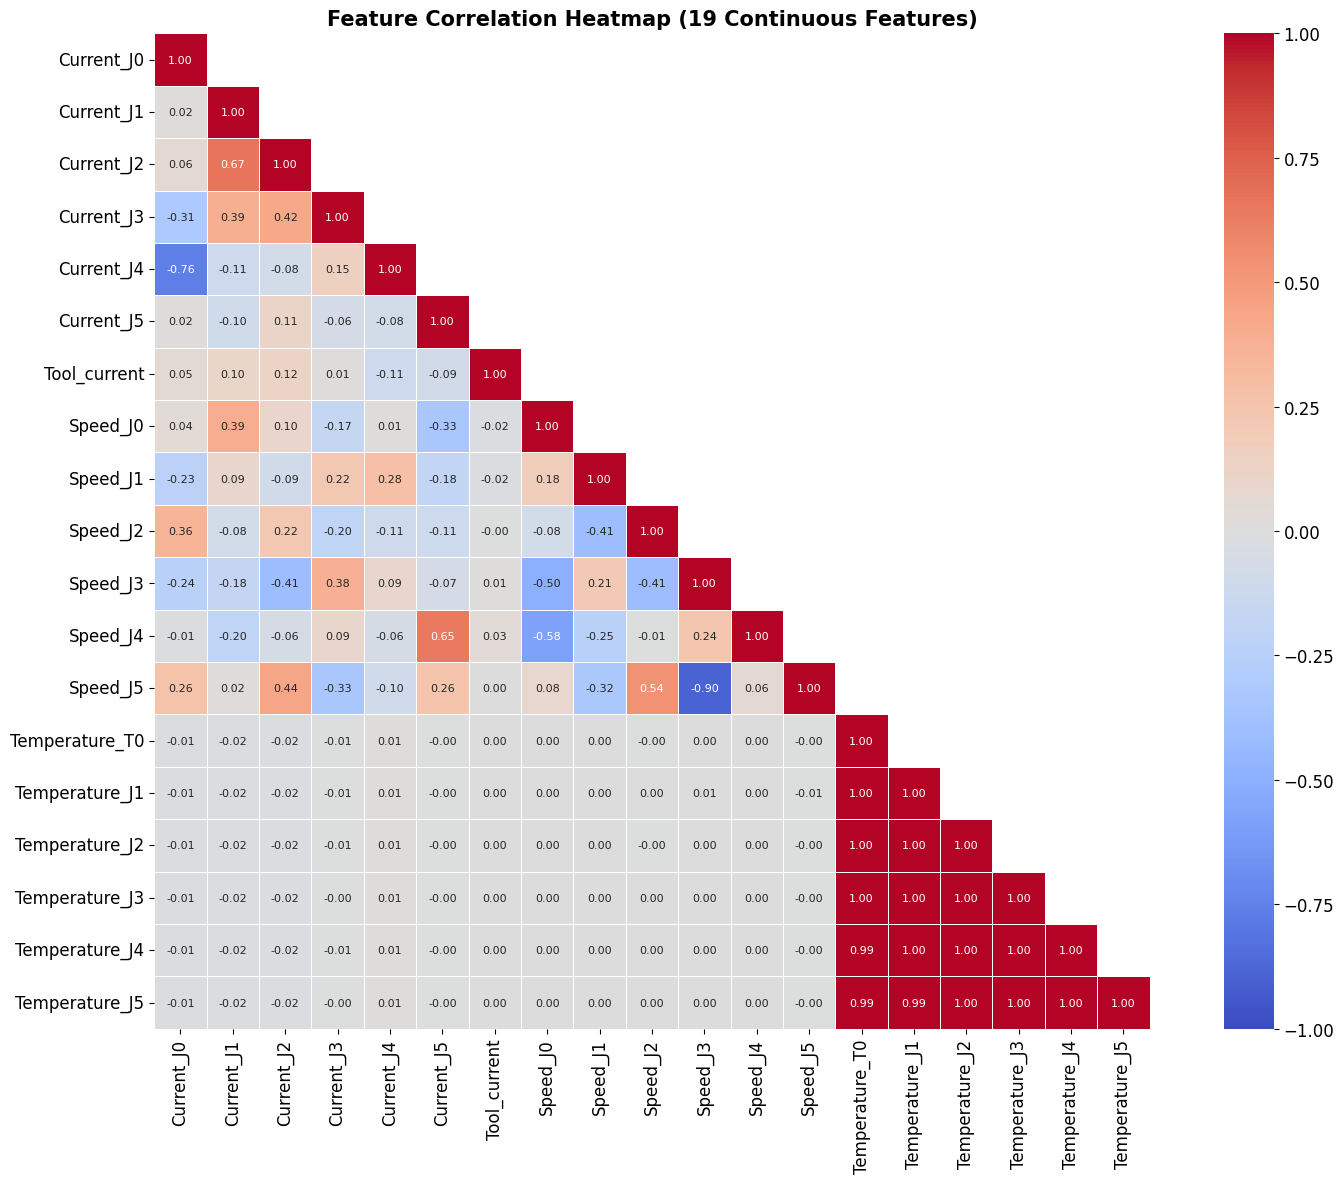


[|상관계수| > 0.7 인 피처 쌍]
  Current_J0 ↔ Current_J4: r = -0.758
  Speed_J3 ↔ Speed_J5: r = -0.895
  Temperature_T0 ↔ Temperature_J1: r = 0.999
  Temperature_T0 ↔ Temperature_J2: r = 0.999
  Temperature_T0 ↔ Temperature_J3: r = 0.996
  Temperature_T0 ↔ Temperature_J4: r = 0.994
  Temperature_T0 ↔ Temperature_J5: r = 0.993
  Temperature_J1 ↔ Temperature_J2: r = 1.000
  Temperature_J1 ↔ Temperature_J3: r = 0.998
  Temperature_J1 ↔ Temperature_J4: r = 0.996
  Temperature_J1 ↔ Temperature_J5: r = 0.995
  Temperature_J2 ↔ Temperature_J3: r = 0.999
  Temperature_J2 ↔ Temperature_J4: r = 0.997
  Temperature_J2 ↔ Temperature_J5: r = 0.997
  Temperature_J3 ↔ Temperature_J4: r = 0.999
  Temperature_J3 ↔ Temperature_J5: r = 0.998
  Temperature_J4 ↔ Temperature_J5: r = 0.999


In [5]:
# ── 전체 연속형 피처(19개) 상관관계 ──
fig, ax = plt.subplots(figsize=(16, 12))
corr_matrix = df_clean[group_C].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            square=True, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap (19 Continuous Features)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# 높은 상관관계 쌍 출력
print("\n[|상관계수| > 0.7 인 피처 쌍]")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: r = {r:.3f}")

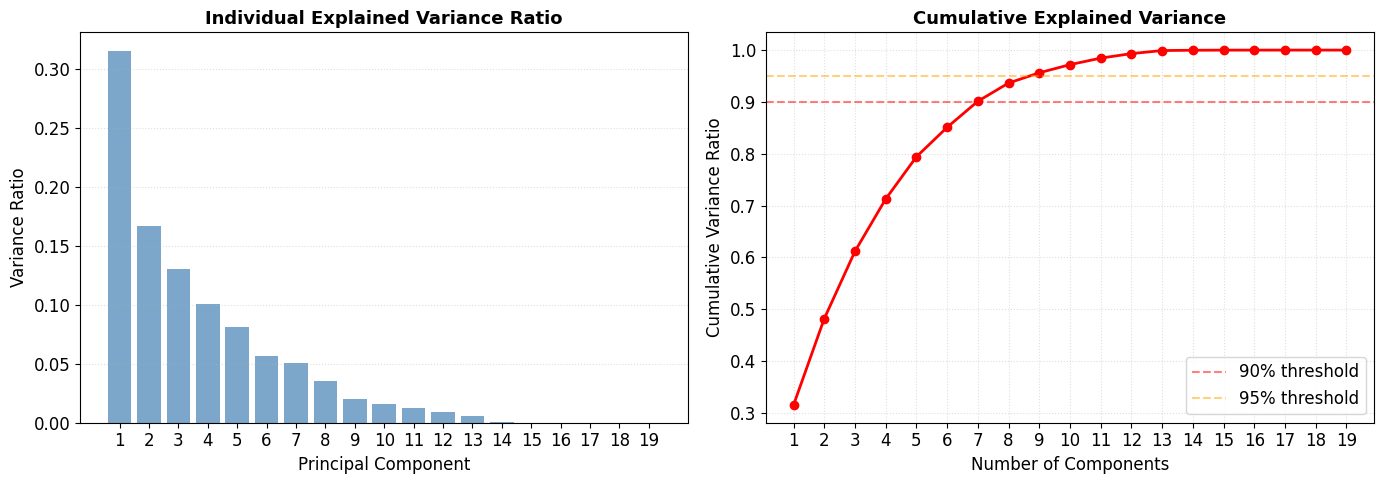


  90% 분산 설명: PC 7개 필요
  95% 분산 설명: PC 9개 필요

  → PCA는 시각화(2D)에만 활용, 클러스터링은 원본 피처로 수행


In [6]:
# ── 19개 피처의 PCA 분산 설명비율 → 차원축소 필요성 판단 ──
X_all = df_clean[group_C].values
scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X_all)

pca_full = PCA(random_state=42)
pca_full.fit(X_all_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 개별 분산 설명비율
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, color='steelblue', alpha=0.7)
axes[0].set_title('Individual Explained Variance Ratio', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Ratio')
axes[0].set_xticks(range(1, 20))
axes[0].grid(True, linestyle=':', alpha=0.4, axis='y')

# 누적 분산 설명비율
axes[1].plot(range(1, len(cum_var)+1), cum_var, 'ro-', linewidth=2, markersize=6)
axes[1].axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='90% threshold')
axes[1].axhline(y=0.95, color='orange', linestyle='--', alpha=0.5, label='95% threshold')
axes[1].set_title('Cumulative Explained Variance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Ratio')
axes[1].set_xticks(range(1, 20))
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

# 90%, 95% 도달 PC 수 출력
n_90 = np.argmax(cum_var >= 0.9) + 1
n_95 = np.argmax(cum_var >= 0.95) + 1
print(f"\n  90% 분산 설명: PC {n_90}개 필요")
print(f"  95% 분산 설명: PC {n_95}개 필요")
print(f"\n  → PCA는 시각화(2D)에만 활용, 클러스터링은 원본 피처로 수행")

## Group A: 전류 변수 (7개)

### Group A: 전류 변수 (7개)
`Current_J0~J5` + `Tool_current` — 로봇의 전기적 부하 상태를 대표하는 변수군.
물리적으로 가장 직접적인 의미를 가지며, 하중에 의해 가장 크게 영향받는 변수.

Group A: 7개 피처, 7355개 샘플
피처: ['Current_J0', 'Current_J1', 'Current_J2', 'Current_J3', 'Current_J4', 'Current_J5', 'Tool_current']



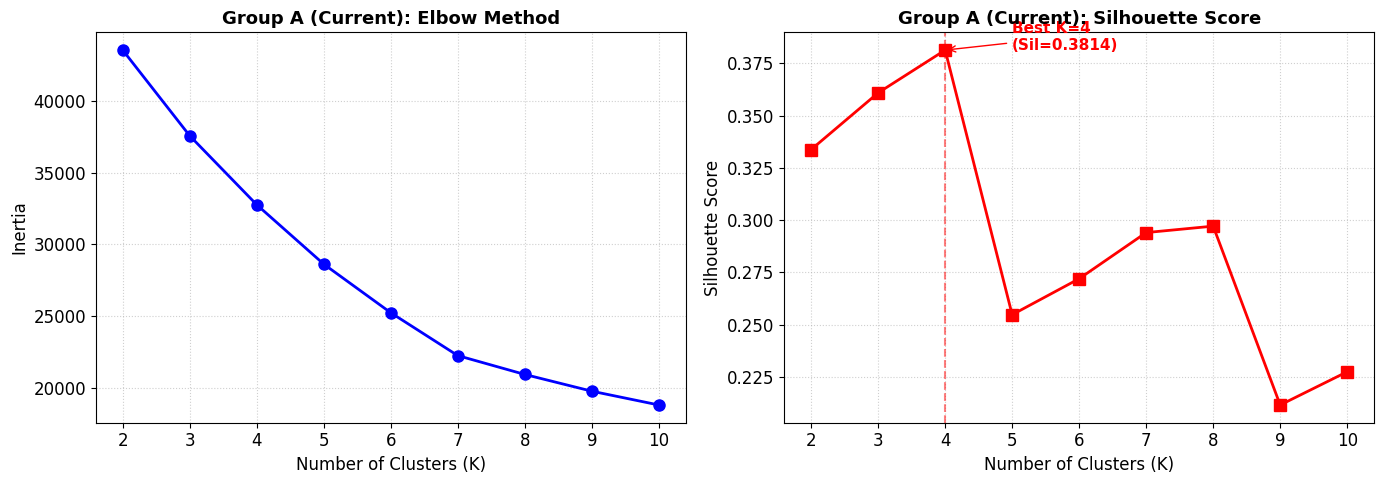


[Group A (Current)] K값별 Silhouette Score:
  K= 2 → Silhouette = 0.3338
  K= 3 → Silhouette = 0.3609
  K= 4 → Silhouette = 0.3814 ◀ BEST
  K= 5 → Silhouette = 0.2548
  K= 6 → Silhouette = 0.2720
  K= 7 → Silhouette = 0.2940
  K= 8 → Silhouette = 0.2971
  K= 9 → Silhouette = 0.2116
  K=10 → Silhouette = 0.2275


In [7]:
# ── Group A: 전류 7개 변수 스케일링 ──
X_A = df_clean[group_A].values
scaler_A = StandardScaler()
X_A_scaled = scaler_A.fit_transform(X_A)

print(f"Group A: {len(group_A)}개 피처, {X_A_scaled.shape[0]}개 샘플")
print(f"피처: {group_A}\n")

# Elbow + Silhouette 분석
K_list_A, inertias_A, sil_scores_A = evaluate_k_range(X_A_scaled)
best_k_A = plot_elbow_silhouette(K_list_A, inertias_A, sil_scores_A, 'Group A (Current)')

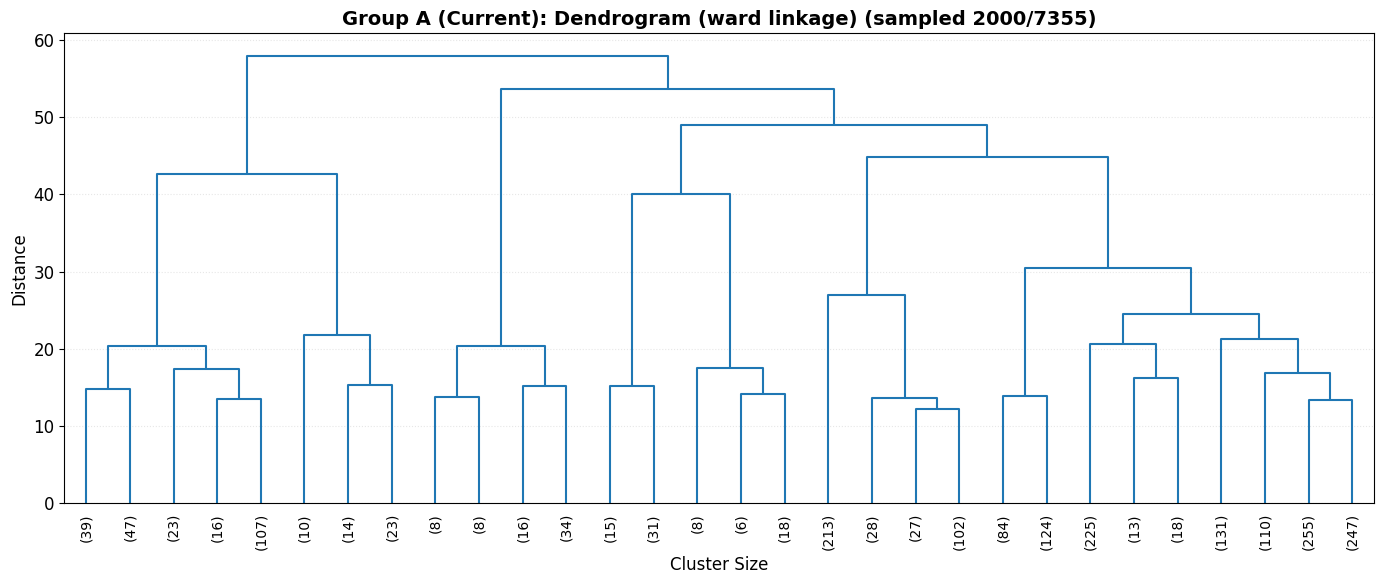

  → Dendrogram에서 자연스러운 군집 개수를 시각적으로 확인하세요.
  → 높은 거리에서 병합되는 가지 수 = 자연스러운 클러스터 수


In [8]:
# ── Group A: 계층적 클러스터링 Dendrogram ──
plot_dendrogram_truncated(X_A_scaled, 'Group A (Current)', method='ward', p=30)
print("  → Dendrogram에서 자연스러운 군집 개수를 시각적으로 확인하세요.")
print("  → 높은 거리에서 병합되는 가지 수 = 자연스러운 클러스터 수")

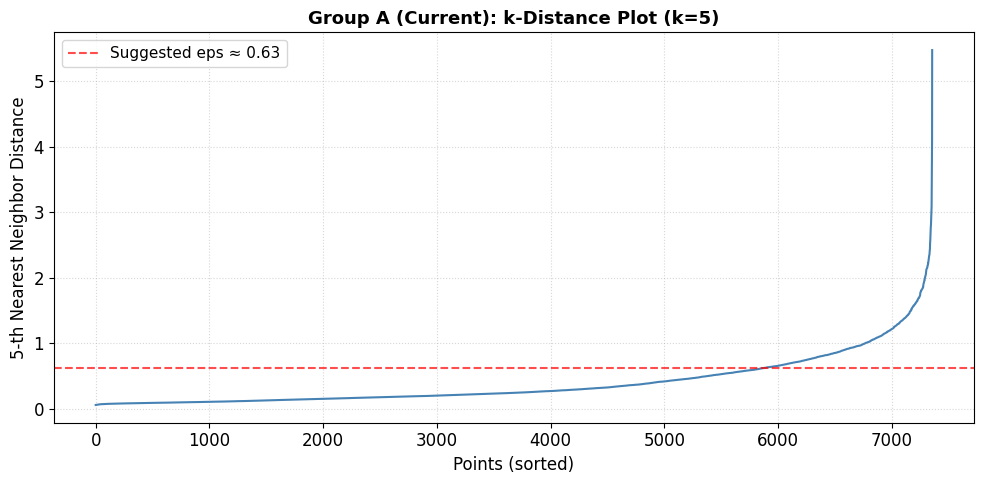

  제안 eps ≈ 0.63

  eps 후보: [np.float64(0.5), np.float64(0.63), np.float64(0.75)]

[DBSCAN Grid Search — Group A]
 eps  min_samples  n_clusters  n_noise  noise_ratio  silhouette
0.50            5          39     1670    22.705642    0.064873
0.50           10          10     2099    28.538409    0.153129
0.50           15          10     2254    30.645819    0.126234
0.63            5          45     1121    15.241332    0.044463
0.63           10          13     1641    22.311353    0.123399
0.63           15           8     1852    25.180150    0.116341
0.75            5          43      807    10.972128    0.035689
0.75           10          15     1238    16.832087    0.273229
0.75           15          11     1526    20.747791    0.308194


In [9]:
# ── Group A: DBSCAN eps 후보 탐색 ──
eps_suggestion_A = find_dbscan_eps(X_A_scaled, k=5, group_name='Group A (Current)')

# eps 후보 3개로 그리드 탐색
eps_candidates_A = [
    round(eps_suggestion_A * 0.8, 2),
    round(eps_suggestion_A, 2),
    round(eps_suggestion_A * 1.2, 2)
]
print(f"\n  eps 후보: {eps_candidates_A}")
print(f"\n[DBSCAN Grid Search — Group A]")
dbscan_results_A = run_dbscan_grid(X_A_scaled, eps_candidates_A, min_samples_list=[5, 10, 15])

In [11]:
# ══════════════════════════════════════════════════════════
# ⚠️ 아래 값들을 위 분석 결과를 보고 조정하세요
# ══════════════════════════════════════════════════════════
OPTIMAL_K_A = best_k_A  # Elbow+Silhouette 결과 기반 (위 Cell에서 자동 설정됨)

# DBSCAN: Grid Search에서 가장 좋은 (eps, min_samples) 선택
# → silhouette가 가장 높고 noise_ratio가 적당한 조합
best_db_A = dbscan_results_A[dbscan_results_A['silhouette'] > 0].sort_values(
    'silhouette', ascending=False)
if len(best_db_A) > 0:
    DBSCAN_EPS_A = best_db_A.iloc[0]['eps']
    DBSCAN_MS_A = int(best_db_A.iloc[0]['min_samples'])
else:
    DBSCAN_EPS_A = eps_suggestion_A
    DBSCAN_MS_A = 5

print(f"선택된 파라미터: K={OPTIMAL_K_A}, DBSCAN(eps={DBSCAN_EPS_A}, min_samples={DBSCAN_MS_A})")

# 3개 알고리즘 실행
results_A = run_clustering_pipeline(
    X_A_scaled, OPTIMAL_K_A, DBSCAN_EPS_A, DBSCAN_MS_A, 'Group A (Current)'
)

선택된 파라미터: K=4, DBSCAN(eps=0.75, min_samples=15)

[Group A (Current)] 3개 알고리즘 비교 결과
Algorithm             K   Silhouette    Noise
---------------------------------------------
K-Means               4       0.3814        0
Agglomerative         4       0.2234        0
DBSCAN               11       0.3082     1526


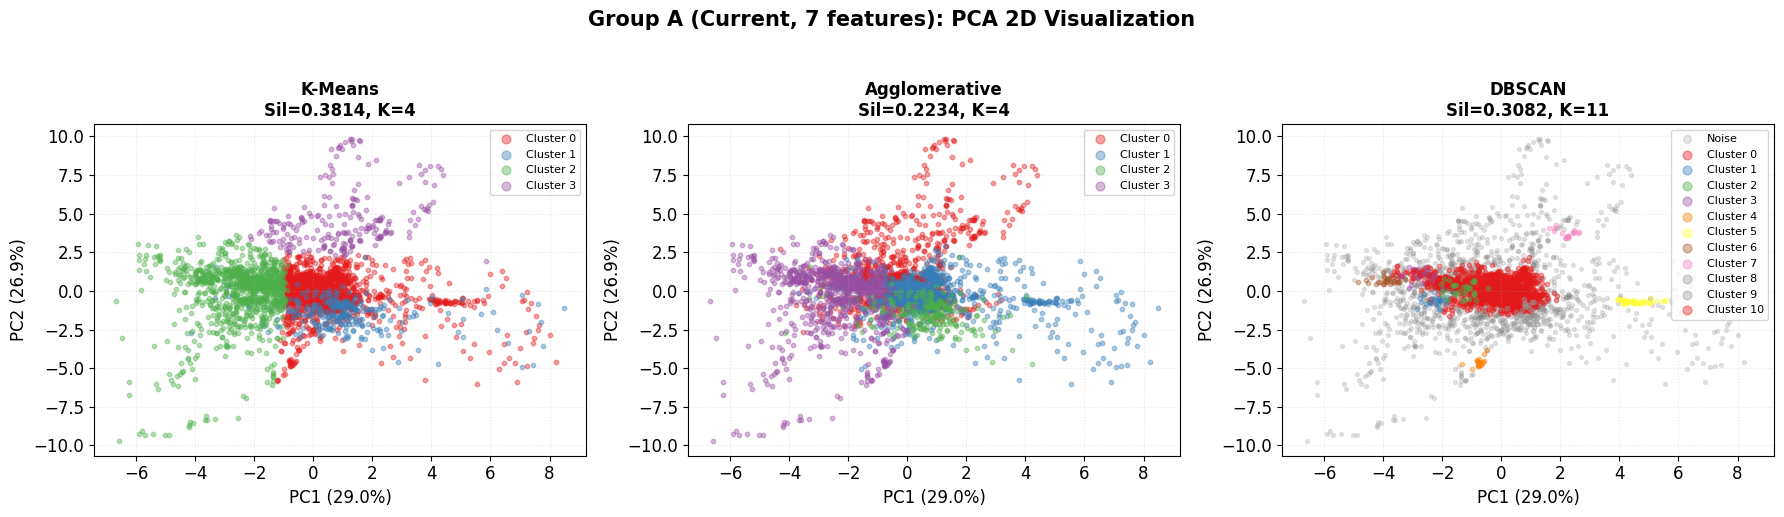

In [12]:
# ── Group A: PCA 2D 시각화 ──
plot_pca_comparison(X_A_scaled, results_A, 'Group A (Current, 7 features)')

## Group B: 전류 + 속도 (13개)

### Group B: 전류 + 속도 (13개)
전류 7개 + 속도 6개 — 로봇의 동적 운영 상태를 포착.
속도 정보가 추가되면 "같은 전류라도 다른 동작 상태"를 구분할 수 있는지 확인.

Group B: 13개 피처, 7355개 샘플



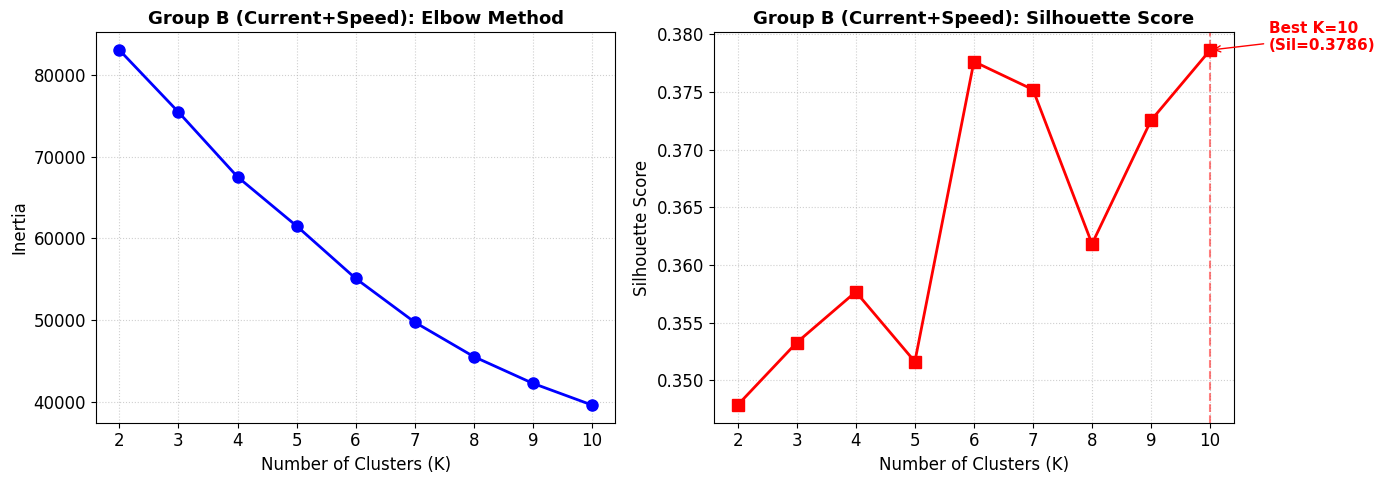


[Group B (Current+Speed)] K값별 Silhouette Score:
  K= 2 → Silhouette = 0.3479
  K= 3 → Silhouette = 0.3533
  K= 4 → Silhouette = 0.3577
  K= 5 → Silhouette = 0.3516
  K= 6 → Silhouette = 0.3776
  K= 7 → Silhouette = 0.3752
  K= 8 → Silhouette = 0.3618
  K= 9 → Silhouette = 0.3726
  K=10 → Silhouette = 0.3786 ◀ BEST


In [13]:
# ── Group B: 전류 + 속도 13개 변수 ──
X_B = df_clean[group_B].values
scaler_B = StandardScaler()
X_B_scaled = scaler_B.fit_transform(X_B)

print(f"Group B: {len(group_B)}개 피처, {X_B_scaled.shape[0]}개 샘플\n")

K_list_B, inertias_B, sil_scores_B = evaluate_k_range(X_B_scaled)
best_k_B = plot_elbow_silhouette(K_list_B, inertias_B, sil_scores_B, 'Group B (Current+Speed)')

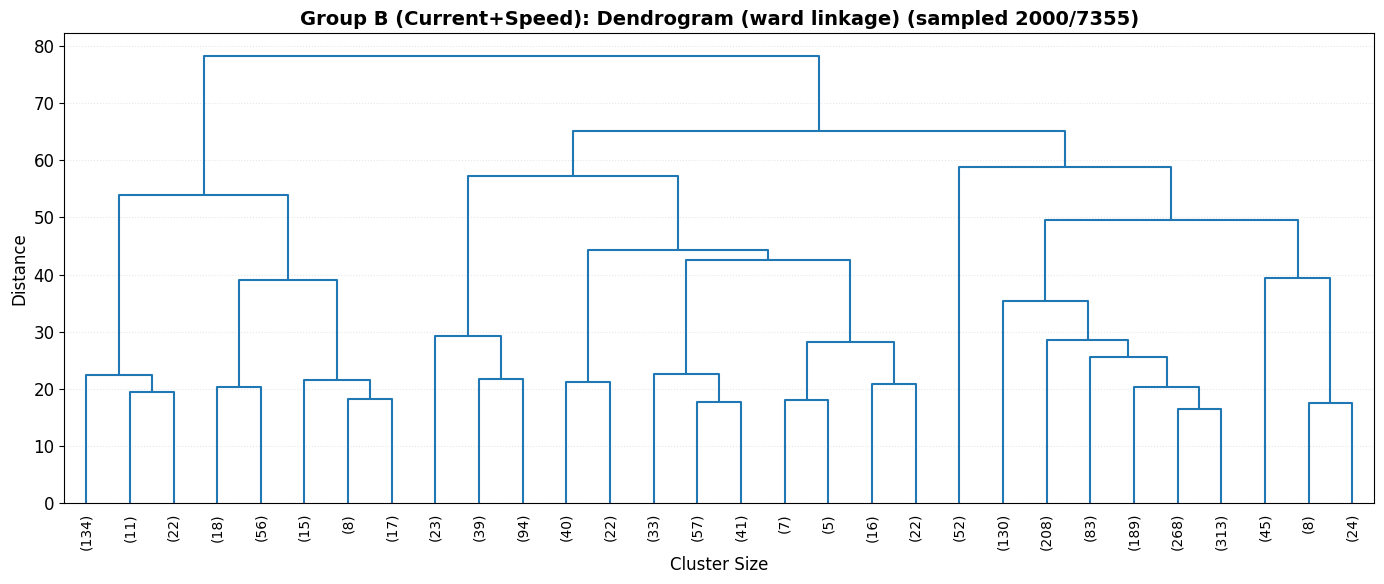

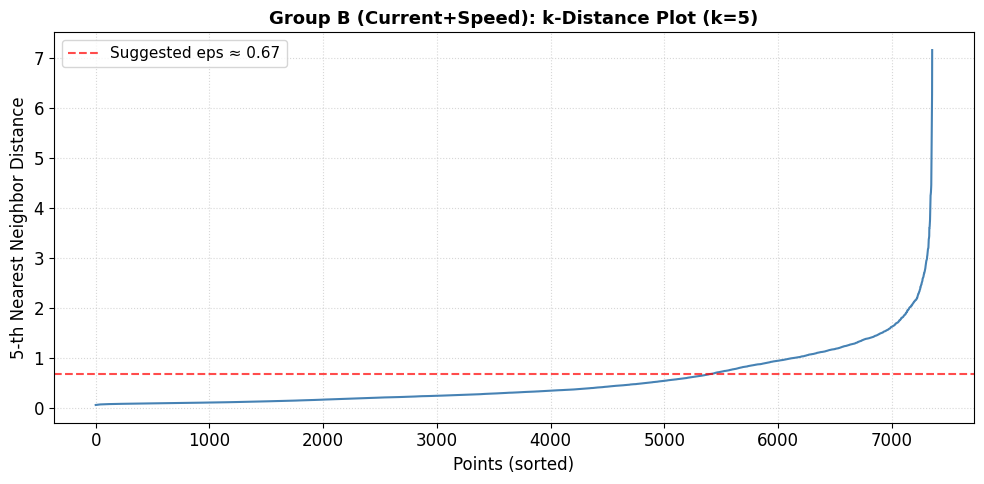

  제안 eps ≈ 0.67

[DBSCAN Grid Search — Group B]
 eps  min_samples  n_clusters  n_noise  noise_ratio  silhouette
0.54            5          53     2086    28.361659    0.131838
0.54           10          17     2595    35.282121    0.293232
0.54           15          13     2848    38.721958    0.318979
0.67            5          50     1730    23.521414    0.077958
0.67           10          22     2189    29.762067    0.232228
0.67           15          16     2407    32.726037    0.201460
0.80            5          58     1409    19.157036    0.069234
0.80           10          24     1907    25.927940    0.121436
0.80           15          15     2152    29.259007    0.374516


In [14]:
# ── Group B: Dendrogram ──
plot_dendrogram_truncated(X_B_scaled, 'Group B (Current+Speed)', method='ward', p=30)

# ── Group B: DBSCAN eps 탐색 ──
eps_suggestion_B = find_dbscan_eps(X_B_scaled, k=5, group_name='Group B (Current+Speed)')
eps_candidates_B = [
    round(eps_suggestion_B * 0.8, 2),
    round(eps_suggestion_B, 2),
    round(eps_suggestion_B * 1.2, 2)
]
print(f"\n[DBSCAN Grid Search — Group B]")
dbscan_results_B = run_dbscan_grid(X_B_scaled, eps_candidates_B, min_samples_list=[5, 10, 15])

In [15]:
OPTIMAL_K_B = best_k_B

best_db_B = dbscan_results_B[dbscan_results_B['silhouette'] > 0].sort_values(
    'silhouette', ascending=False)
if len(best_db_B) > 0:
    DBSCAN_EPS_B = best_db_B.iloc[0]['eps']
    DBSCAN_MS_B = int(best_db_B.iloc[0]['min_samples'])
else:
    DBSCAN_EPS_B = eps_suggestion_B
    DBSCAN_MS_B = 5

print(f"선택된 파라미터: K={OPTIMAL_K_B}, DBSCAN(eps={DBSCAN_EPS_B}, min_samples={DBSCAN_MS_B})")

results_B = run_clustering_pipeline(
    X_B_scaled, OPTIMAL_K_B, DBSCAN_EPS_B, DBSCAN_MS_B, 'Group B (Current+Speed)'
)

선택된 파라미터: K=10, DBSCAN(eps=0.8, min_samples=15)

[Group B (Current+Speed)] 3개 알고리즘 비교 결과
Algorithm             K   Silhouette    Noise
---------------------------------------------
K-Means              10       0.3786        0
Agglomerative        10       0.3559        0
DBSCAN               15       0.3745     2152


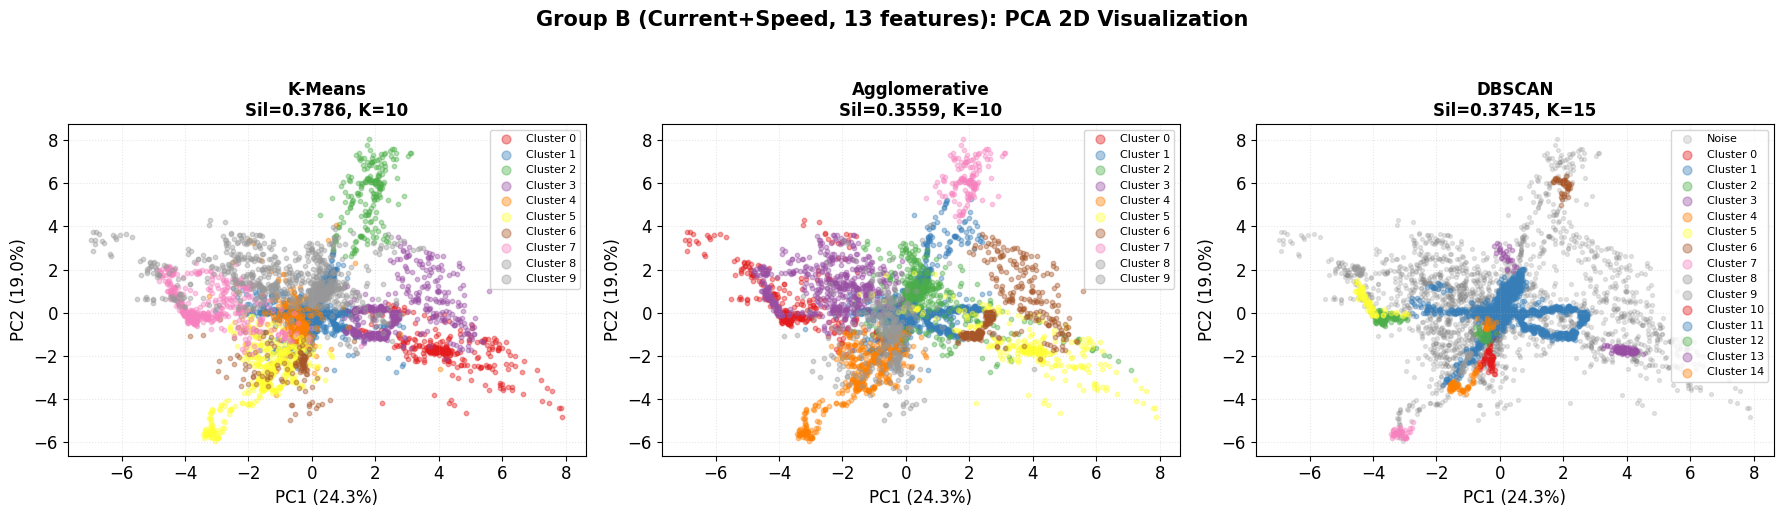

In [16]:
plot_pca_comparison(X_B_scaled, results_B, 'Group B (Current+Speed, 13 features)')

## Group C: 전체 19개

### Group C: 전체 19개 변수
전류 7 + 속도 6 + 온도 6 — 로봇의 종합 운영 상태.
온도를 추가하면 장시간 운전에 따른 열적 상태까지 포함한 군집이 형성되는지 확인.

Group C: 19개 피처, 7355개 샘플



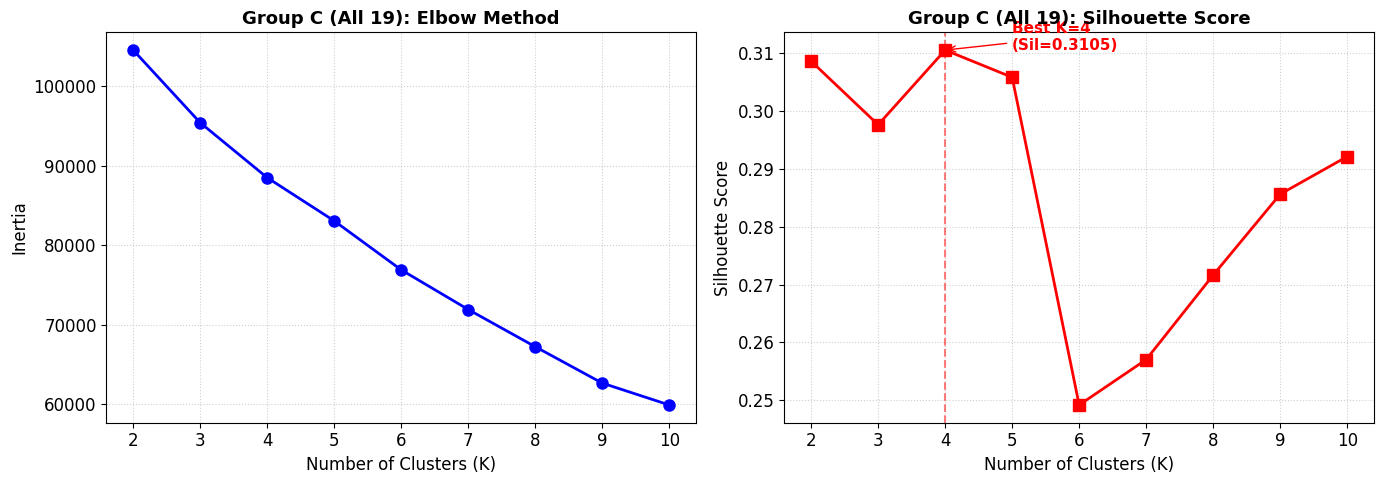


[Group C (All 19)] K값별 Silhouette Score:
  K= 2 → Silhouette = 0.3086
  K= 3 → Silhouette = 0.2976
  K= 4 → Silhouette = 0.3105 ◀ BEST
  K= 5 → Silhouette = 0.3058
  K= 6 → Silhouette = 0.2492
  K= 7 → Silhouette = 0.2570
  K= 8 → Silhouette = 0.2716
  K= 9 → Silhouette = 0.2856
  K=10 → Silhouette = 0.2921


In [17]:
# ── Group C: 전체 19개 변수 ──
X_C = df_clean[group_C].values
scaler_C = StandardScaler()
X_C_scaled = scaler_C.fit_transform(X_C)

print(f"Group C: {len(group_C)}개 피처, {X_C_scaled.shape[0]}개 샘플\n")

K_list_C, inertias_C, sil_scores_C = evaluate_k_range(X_C_scaled)
best_k_C = plot_elbow_silhouette(K_list_C, inertias_C, sil_scores_C, 'Group C (All 19)')

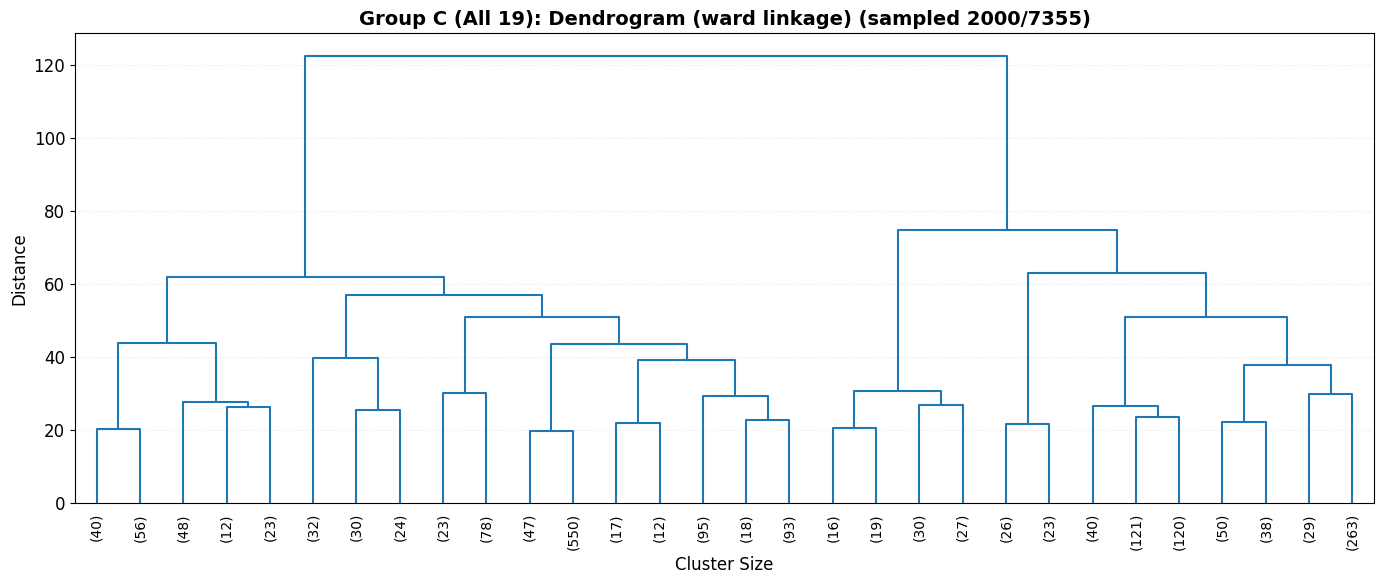

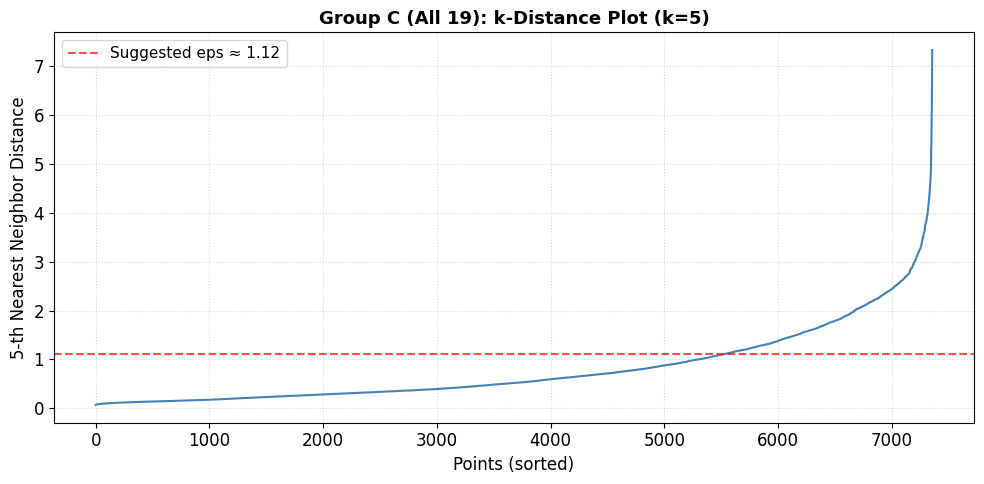

  제안 eps ≈ 1.12

[DBSCAN Grid Search — Group C]
 eps  min_samples  n_clusters  n_noise  noise_ratio  silhouette
0.90            5          59     1967    26.743712    0.069180
0.90           10          23     2510    34.126445    0.274864
0.90           15          22     2705    36.777702    0.293954
1.12            5          56     1497    20.353501    0.166800
1.12           10          26     1993    27.097213    0.209310
1.12           15          17     2327    31.638341    0.307309
1.35            5          53     1091    14.833447    0.101508
1.35           10          23     1573    21.386812    0.227940
1.35           15          16     1888    25.669613    0.317928


In [18]:
plot_dendrogram_truncated(X_C_scaled, 'Group C (All 19)', method='ward', p=30)

eps_suggestion_C = find_dbscan_eps(X_C_scaled, k=5, group_name='Group C (All 19)')
eps_candidates_C = [
    round(eps_suggestion_C * 0.8, 2),
    round(eps_suggestion_C, 2),
    round(eps_suggestion_C * 1.2, 2)
]
print(f"\n[DBSCAN Grid Search — Group C]")
dbscan_results_C = run_dbscan_grid(X_C_scaled, eps_candidates_C, min_samples_list=[5, 10, 15])

In [19]:
OPTIMAL_K_C = best_k_C

best_db_C = dbscan_results_C[dbscan_results_C['silhouette'] > 0].sort_values(
    'silhouette', ascending=False)
if len(best_db_C) > 0:
    DBSCAN_EPS_C = best_db_C.iloc[0]['eps']
    DBSCAN_MS_C = int(best_db_C.iloc[0]['min_samples'])
else:
    DBSCAN_EPS_C = eps_suggestion_C
    DBSCAN_MS_C = 5

print(f"선택된 파라미터: K={OPTIMAL_K_C}, DBSCAN(eps={DBSCAN_EPS_C}, min_samples={DBSCAN_MS_C})")

results_C = run_clustering_pipeline(
    X_C_scaled, OPTIMAL_K_C, DBSCAN_EPS_C, DBSCAN_MS_C, 'Group C (All 19)'
)

선택된 파라미터: K=4, DBSCAN(eps=1.35, min_samples=15)

[Group C (All 19)] 3개 알고리즘 비교 결과
Algorithm             K   Silhouette    Noise
---------------------------------------------
K-Means               4       0.3105        0
Agglomerative         4       0.2888        0
DBSCAN               16       0.3179     1888


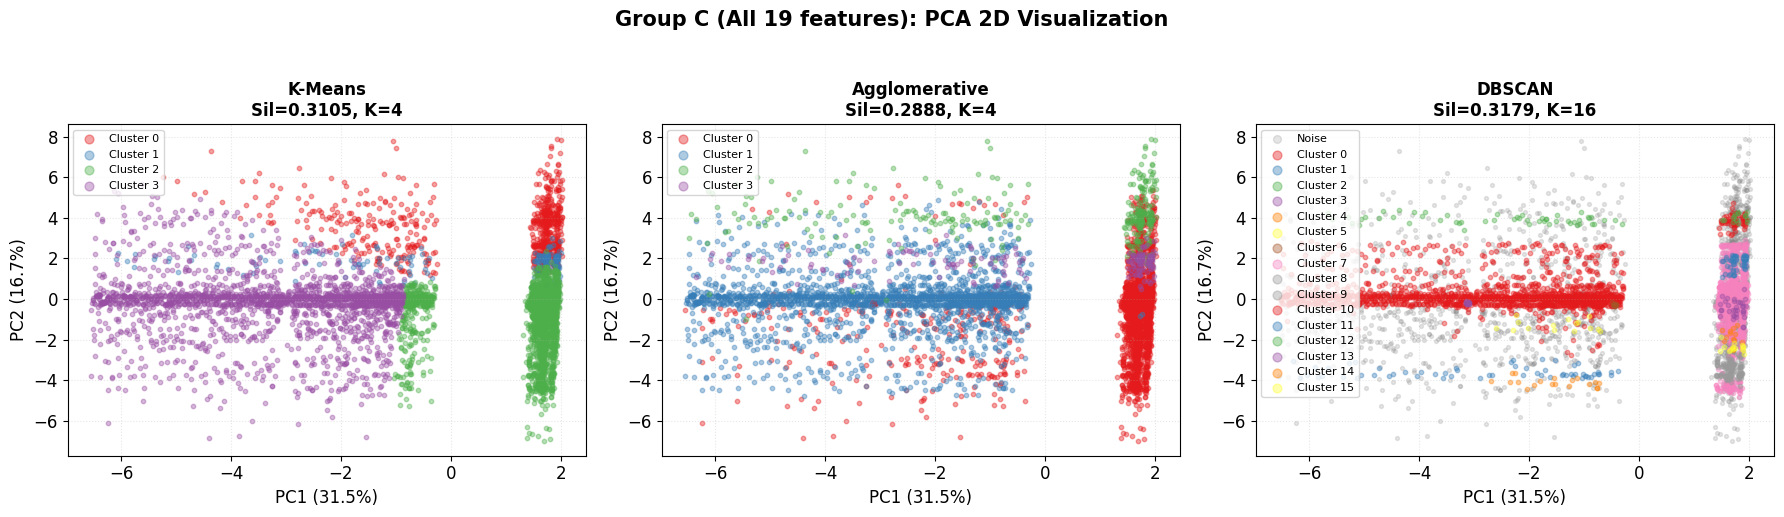

In [20]:
plot_pca_comparison(X_C_scaled, results_C, 'Group C (All 19 features)')

        종합 비교: Feature Group × Algorithm
                      Group     Algorithm  K  Silhouette  Noise
       Group A (Current, 7)       K-Means  4    0.381350      0
       Group A (Current, 7) Agglomerative  4    0.223394      0
       Group A (Current, 7)        DBSCAN 11    0.308194   1526
Group B (Current+Speed, 13)       K-Means 10    0.378643      0
Group B (Current+Speed, 13) Agglomerative 10    0.355905      0
Group B (Current+Speed, 13)        DBSCAN 15    0.374516   2152
          Group C (All, 19)       K-Means  4    0.310514      0
          Group C (All, 19) Agglomerative  4    0.288758      0
          Group C (All, 19)        DBSCAN 16    0.317928   1888


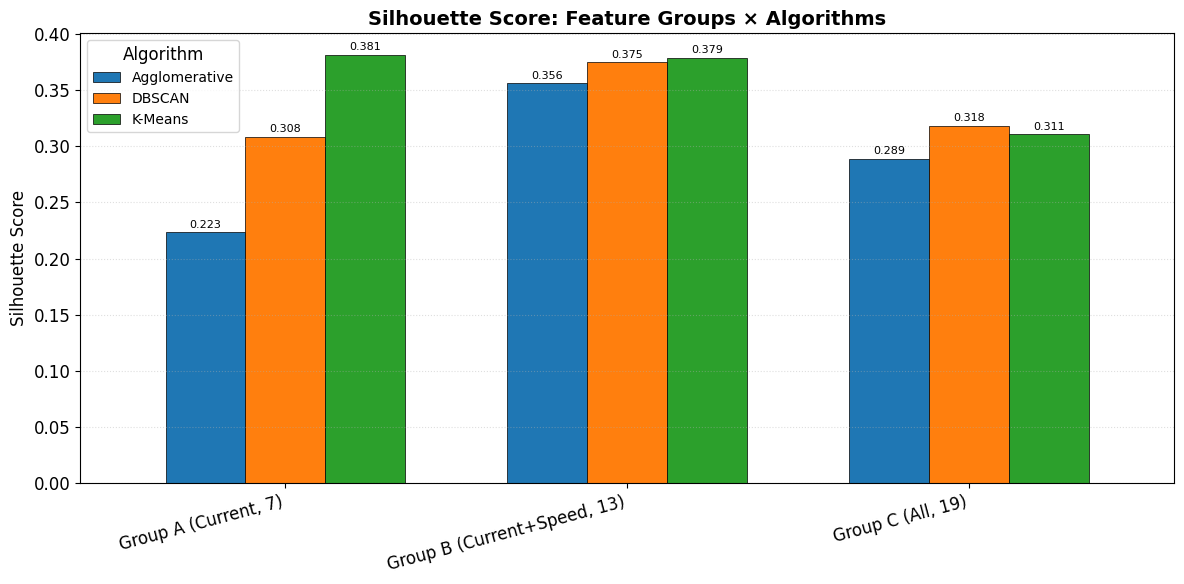


🏆 최적 조합: Group A (Current, 7) + K-Means
   K = 4, Silhouette = 0.3814


In [21]:
# ══════════════════════════════════════════════
# 종합 비교: 3 Groups × 3 Algorithms
# ══════════════════════════════════════════════

summary_rows = []
all_results = {
    'Group A (Current, 7)': results_A,
    'Group B (Current+Speed, 13)': results_B,
    'Group C (All, 19)': results_C
}

for group_name, results in all_results.items():
    for algo_name, res in results.items():
        summary_rows.append({
            'Group': group_name,
            'Algorithm': algo_name,
            'K': res['n_clusters'],
            'Silhouette': res['silhouette'],
            'Noise': res.get('n_noise', 0)
        })

df_summary = pd.DataFrame(summary_rows)

print("=" * 75)
print("        종합 비교: Feature Group × Algorithm")
print("=" * 75)
print(df_summary.to_string(index=False))

# 시각화: Silhouette 비교 Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))
pivot = df_summary.pivot(index='Group', columns='Algorithm', values='Silhouette')
pivot.plot(kind='bar', ax=ax, width=0.7, edgecolor='black', linewidth=0.5)
ax.set_title('Silhouette Score: Feature Groups × Algorithms', fontsize=14, fontweight='bold')
ax.set_ylabel('Silhouette Score')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.legend(title='Algorithm', fontsize=10)
ax.grid(True, linestyle=':', alpha=0.4, axis='y')

# 값 표시
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
plt.show()

# 최적 조합 출력
best_row = df_summary.loc[df_summary['Silhouette'].idxmax()]
print(f"\n🏆 최적 조합: {best_row['Group']} + {best_row['Algorithm']}")
print(f"   K = {best_row['K']}, Silhouette = {best_row['Silhouette']:.4f}")

최적 조합: Group A (Current, 7) + K-Means
K = 4
Silhouette = 0.3814

[군집 프로파일] 피처별 평균
              Current_J0  Current_J1  Current_J2  Current_J3  Current_J4  Current_J5  Tool_current
Best_Cluster                                                                                      
0                -0.0241     -2.0719     -1.0470     -0.5000     -0.0349     -0.0005        0.0970
1                 0.1684     -1.9608     -0.9146     -0.5124     -0.3836     -0.0335        0.4595
2                 0.2960     -3.4484     -1.9725     -1.2489     -0.2406      0.0228        0.0863
3                -2.8884     -2.5870     -1.4865     -0.0757      1.9522     -0.0329        0.0868


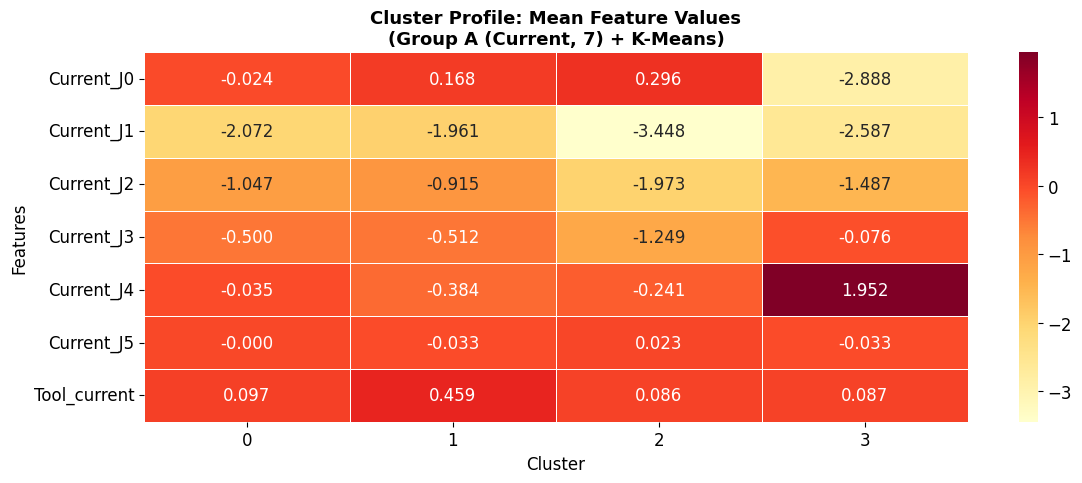

In [22]:
# ══════════════════════════════════════════════
# ⚠️ 최적 조합을 선택하세요 (위 종합 비교 결과 기반)
# 아래 예시는 자동으로 가장 좋은 조합을 선택합니다.
# 필요시 수동으로 변경하세요.
# ══════════════════════════════════════════════

# 자동 선택: 가장 높은 Silhouette 조합
best_group_name = best_row['Group']
best_algo_name = best_row['Algorithm']

# 해당 그룹의 피처와 레이블 매핑
group_map = {
    'Group A (Current, 7)': (group_A, X_A_scaled, results_A),
    'Group B (Current+Speed, 13)': (group_B, X_B_scaled, results_B),
    'Group C (All, 19)': (group_C, X_C_scaled, results_C),
}

best_features, best_X_scaled, best_results = group_map[best_group_name]
best_labels = best_results[best_algo_name]['labels']

# 군집 라벨을 데이터프레임에 추가
df_clean['Best_Cluster'] = best_labels

print(f"최적 조합: {best_group_name} + {best_algo_name}")
print(f"K = {best_results[best_algo_name]['n_clusters']}")
print(f"Silhouette = {best_results[best_algo_name]['silhouette']:.4f}")

# 군집별 피처 평균 (프로파일)
print(f"\n{'='*70}")
print(f"[군집 프로파일] 피처별 평균")
print(f"{'='*70}")

# 노이즈(-1) 제외
profile_mask = df_clean['Best_Cluster'] != -1
profile = df_clean[profile_mask].groupby('Best_Cluster')[best_features].mean()
print(profile.round(4).to_string())

# 히트맵: 군집별 평균 (StandardScaler 역변환 값)
fig, ax = plt.subplots(figsize=(max(12, len(best_features)*0.8), 5))
sns.heatmap(profile.T, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title(f'Cluster Profile: Mean Feature Values\n({best_group_name} + {best_algo_name})',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Features')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

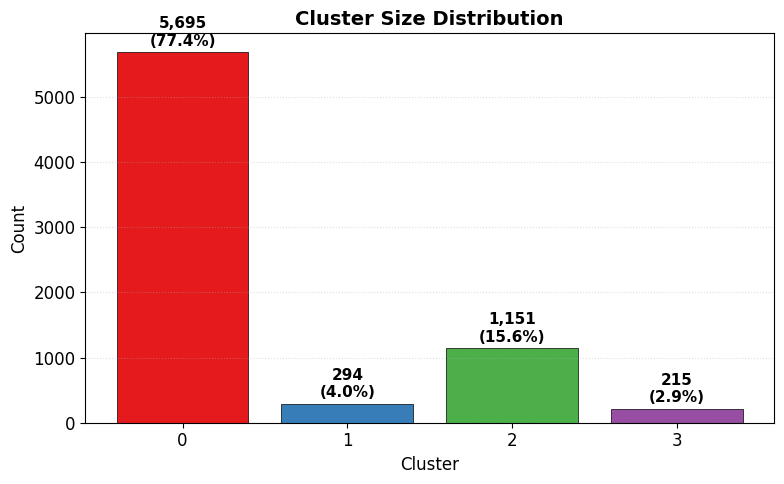

In [23]:
# ── 군집별 크기 ──
cluster_counts = df_clean[profile_mask]['Best_Cluster'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.Set1(range(len(cluster_counts)))
bars = ax.bar(cluster_counts.index.astype(str), cluster_counts.values,
              color=colors, edgecolor='black', linewidth=0.5)
for bar, count in zip(bars, cluster_counts.values):
    pct = count / cluster_counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_title('Cluster Size Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Count')
ax.grid(True, linestyle=':', alpha=0.4, axis='y')
plt.tight_layout()
plt.show()

# DBSCAN 노이즈가 있는 경우
n_noise = (df_clean['Best_Cluster'] == -1).sum()
if n_noise > 0:
    print(f"\n  ⚠️ Noise points (label=-1): {n_noise}개 ({n_noise/len(df_clean)*100:.1f}%)")

[외부 검증] 군집별 에러 발생률
         Total  Grip Lost (%)  Protective Stop (%)
Cluster                                           
0         5695           4.09                 1.84
1          294           0.68                 1.02
2         1151           0.52                14.34
3          215           0.93                 2.33


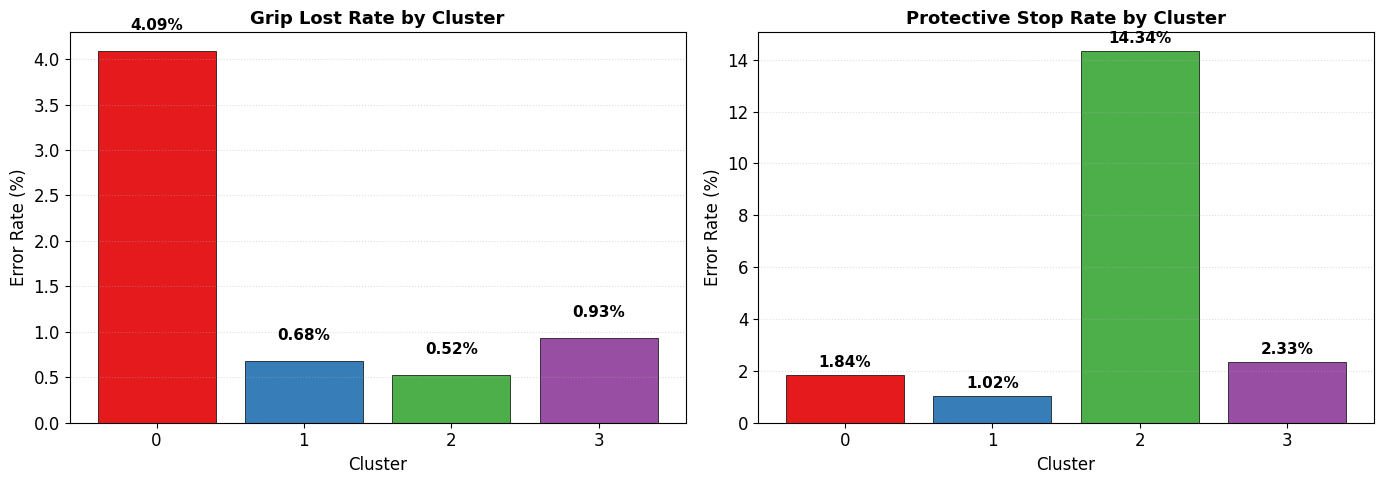


[외부 검증 지표]
  Adjusted Rand Index (ARI): 0.0489
  Normalized Mutual Info (NMI): 0.0474

  ARI: -1~1 (1=완벽 일치, 0=랜덤, <0=반일치)
  NMI: 0~1 (1=완벽 일치, 0=무관)

[교차표] Cluster vs Error Type
error_type    GripLost  Normal  ProtectiveStop  Total
Best_Cluster                                         
0                  233    5360             102   5695
1                    2     289               3    294
2                    6     980             165   1151
3                    2     208               5    215
Total              243    6837             275   7355


In [24]:
# ══════════════════════════════════════════════
# 외부 검증: 발견된 군집이 에러와 관련되는가?
# ══════════════════════════════════════════════

# 노이즈 제외
df_valid = df_clean[df_clean['Best_Cluster'] != -1].copy()

# ── 1. 군집별 에러 발생률 ──
error_analysis = []
for c_id in sorted(df_valid['Best_Cluster'].unique()):
    subset = df_valid[df_valid['Best_Cluster'] == c_id]
    n = len(subset)
    grip_rate = subset['grip_lost'].sum() / n * 100
    stop_rate = subset['ProtectiveStop_bool'].sum() / n * 100
    error_analysis.append({
        'Cluster': c_id, 'Total': n,
        'Grip Lost (%)': round(grip_rate, 2),
        'Protective Stop (%)': round(stop_rate, 2)
    })

df_error = pd.DataFrame(error_analysis).set_index('Cluster')
print("=" * 60)
print("[외부 검증] 군집별 에러 발생률")
print("=" * 60)
print(df_error.to_string())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.Set1(range(len(df_error)))

for idx, (col, title) in enumerate([
    ('Grip Lost (%)', 'Grip Lost Rate by Cluster'),
    ('Protective Stop (%)', 'Protective Stop Rate by Cluster')
]):
    ax = axes[idx]
    bars = ax.bar(df_error.index.astype(str), df_error[col],
                  color=colors, edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, df_error[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Error Rate (%)')
    ax.grid(True, linestyle=':', alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

# ── 2. ARI / NMI (에러 라벨과 군집의 일치도) ──
# 복합 에러 라벨 생성
df_valid['error_label'] = 0  # Normal
df_valid.loc[df_valid['ProtectiveStop_bool'], 'error_label'] = 1  # Protective Stop
df_valid.loc[df_valid['grip_lost'], 'error_label'] = 2  # Grip Lost

ari_score = adjusted_rand_score(df_valid['error_label'], df_valid['Best_Cluster'])
nmi_score = normalized_mutual_info_score(df_valid['error_label'], df_valid['Best_Cluster'])

print(f"\n[외부 검증 지표]")
print(f"  Adjusted Rand Index (ARI): {ari_score:.4f}")
print(f"  Normalized Mutual Info (NMI): {nmi_score:.4f}")
print(f"\n  ARI: -1~1 (1=완벽 일치, 0=랜덤, <0=반일치)")
print(f"  NMI: 0~1 (1=완벽 일치, 0=무관)")

# ── 3. 교차표 ──
print(f"\n{'='*60}")
print("[교차표] Cluster vs Error Type")
print(f"{'='*60}")
error_map = {0: 'Normal', 1: 'ProtectiveStop', 2: 'GripLost'}
df_valid['error_type'] = df_valid['error_label'].map(error_map)

ct = pd.crosstab(df_valid['Best_Cluster'], df_valid['error_type'],
                 margins=True, margins_name='Total')
print(ct)

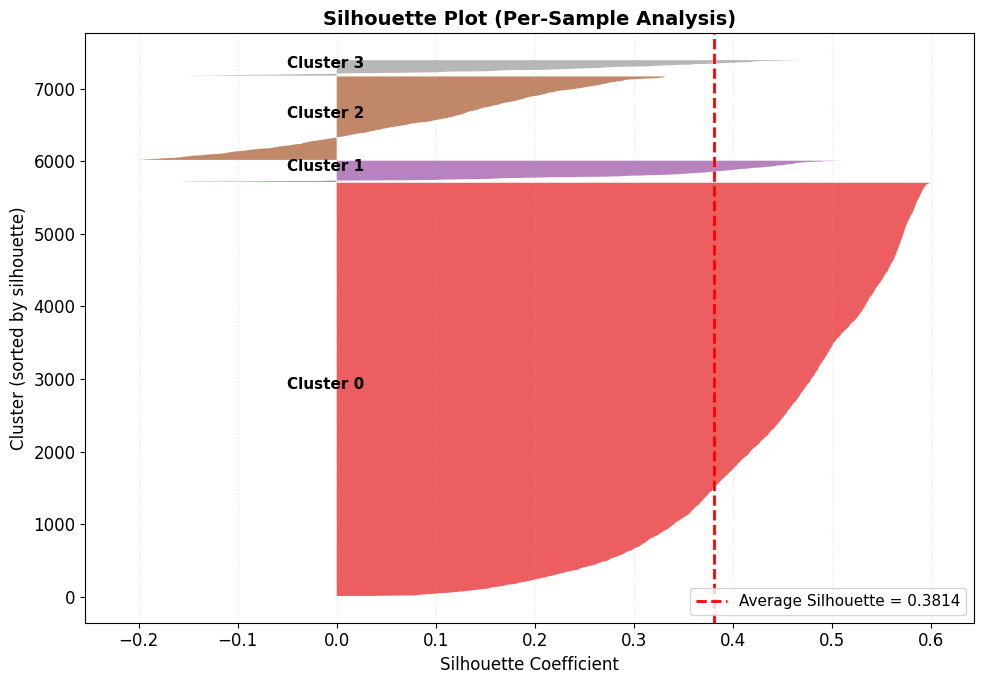

[해석]
  • 모든 샘플의 실루엣이 양수이면: 해당 클러스터 할당이 적절
  • 음수 샘플이 많은 클러스터: 경계가 불명확하거나 다른 군집에 가까운 데이터 존재
  • 클러스터별 실루엣 폭이 균일할수록 좋은 군집화


In [25]:
# ── Silhouette Sample Analysis: 개별 데이터의 실루엣 값 분포 ──
best_X_valid = best_X_scaled[df_clean['Best_Cluster'] != -1]
best_labels_valid = df_clean.loc[df_clean['Best_Cluster'] != -1, 'Best_Cluster'].values

sil_samples = silhouette_samples(best_X_valid, best_labels_valid)
sil_avg = sil_samples.mean()

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10
unique_clusters = sorted(set(best_labels_valid))
colors = plt.cm.Set1(np.linspace(0, 1, len(unique_clusters)))

for idx, c_id in enumerate(unique_clusters):
    cluster_sil = sil_samples[best_labels_valid == c_id]
    cluster_sil.sort()
    size = len(cluster_sil)
    y_upper = y_lower + size

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=colors[idx], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, f'Cluster {c_id}',
            fontsize=11, fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=sil_avg, color='red', linestyle='--', linewidth=2,
           label=f'Average Silhouette = {sil_avg:.4f}')
ax.set_title('Silhouette Plot (Per-Sample Analysis)', fontsize=14, fontweight='bold')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster (sorted by silhouette)')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, linestyle=':', alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("[해석]")
print("  • 모든 샘플의 실루엣이 양수이면: 해당 클러스터 할당이 적절")
print("  • 음수 샘플이 많은 클러스터: 경계가 불명확하거나 다른 군집에 가까운 데이터 존재")
print("  • 클러스터별 실루엣 폭이 균일할수록 좋은 군집화")

In [26]:
print("=" * 75)
print("     UR3 CobotOps 클러스터링 분석 — 최종 결론")
print("=" * 75)

print(f"""
[분석 개요]
  • 데이터: UR3 협동로봇 운영 데이터 ({len(df_clean)}개 관측치)
  • 피처: 3개 그룹 (A: 전류 7개 / B: 전류+속도 13개 / C: 전체 19개)
  • 알고리즘: K-Means, Agglomerative (Ward), DBSCAN
  • 시계열 미반영: 각 행을 독립적 관측치로 취급
  • PCA: 시각화 전용 (클러스터링은 원본 피처 사용)

[기존 분석의 문제점]
  • Tool_current 1D K-Means (Silhouette={sil_1d:.4f})는
    삼봉 분포의 구간 나누기에 불과했음
  • 1개 변수만으로는 다차원 클러스터링의 의미가 없음

[종합 비교 결과]
""")

# 종합표 재출력
print(df_summary.to_string(index=False))

print(f"""
[최적 조합]
  🏆 {best_row['Group']} + {best_row['Algorithm']}
     K = {int(best_row['K'])}, Silhouette = {best_row['Silhouette']:.4f}

[외부 검증]
  ARI = {ari_score:.4f}, NMI = {nmi_score:.4f}
  → 군집이 에러 라벨과 {'유의미한 관련' if ari_score > 0.05 else '약한 관련'}이 있음

[인사이트]
  1. 클러스터링은 '정답 맞추기'가 아닌 '패턴 발견'이 목적
  2. 높은 Silhouette이 반드시 좋은 분석을 의미하지 않음
     (1D에서 0.92가 나왔지만 분석적 가치는 낮았음)
  3. 다차원 피처 공간에서 발견한 군집은
     로봇의 실제 운영 상태를 더 풍부하게 반영함
  4. 발견된 군집과 에러 라벨의 관계는
     예방적 유지보수(Predictive Maintenance)에 활용 가능
""")

     UR3 CobotOps 클러스터링 분석 — 최종 결론

[분석 개요]
  • 데이터: UR3 협동로봇 운영 데이터 (7355개 관측치)
  • 피처: 3개 그룹 (A: 전류 7개 / B: 전류+속도 13개 / C: 전체 19개)
  • 알고리즘: K-Means, Agglomerative (Ward), DBSCAN
  • 시계열 미반영: 각 행을 독립적 관측치로 취급
  • PCA: 시각화 전용 (클러스터링은 원본 피처 사용)

[기존 분석의 문제점]
  • Tool_current 1D K-Means (Silhouette=0.9248)는
    삼봉 분포의 구간 나누기에 불과했음
  • 1개 변수만으로는 다차원 클러스터링의 의미가 없음

[종합 비교 결과]

                      Group     Algorithm  K  Silhouette  Noise
       Group A (Current, 7)       K-Means  4    0.381350      0
       Group A (Current, 7) Agglomerative  4    0.223394      0
       Group A (Current, 7)        DBSCAN 11    0.308194   1526
Group B (Current+Speed, 13)       K-Means 10    0.378643      0
Group B (Current+Speed, 13) Agglomerative 10    0.355905      0
Group B (Current+Speed, 13)        DBSCAN 15    0.374516   2152
          Group C (All, 19)       K-Means  4    0.310514      0
          Group C (All, 19) Agglomerative  4    0.288758      0
          Group C (All, 19)        DBSCAN 16   